In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,497 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121749 files and dire

In [ ]:
import pandas as pd
import numpy as np

# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns

In [ ]:
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

# 랜덤 포레스트

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# export_graphviz: 나무 구조 생성 및 저장
from sklearn.tree import export_graphviz
# graphviz : 나무 구조 시각화  (.dot 확장자 파일 불러오기 등)
import graphviz
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 예측/회귀 Random Forest
from sklearn.ensemble import RandomForestRegressor
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /real_final.csv")
df_raw.head(10)

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340
5,75000,3,1,1,21.10,814.0,5.0,11,12,3,0,8.189650,4.010963
6,86999,0,1,1,23.08,1461.0,5.0,22,11,4,1,8.587905,4.144721
7,36000,0,2,1,11.36,2755.0,8.0,29,8,2,3,10.197194,5.144583
8,64430,0,1,1,20.54,1598.0,5.0,30,11,2,1,8.983740,4.640537
9,65932,0,1,2,22.30,1248.0,5.0,28,12,3,1,8.003119,4.304065


In [ ]:
#engine 열 삭제
df_raw = df_raw.drop('Engine', axis=1)
df_raw

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,5.0,5,8,3,1,9.045262,4.204693
5971,41413,0,1,1,27.28,5.0,28,8,2,1,9.289493,4.234107
5972,39015,1,1,1,17.00,5.0,8,7,3,1,9.508645,4.798761
5973,6000,1,1,1,16.00,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
#목표변수, 설명변수 데이터 지정
df_raw_y = df_raw['log_price']
df_raw_x = df_raw.drop('log_price',axis=1, inplace = False)



총 데이터 수 많지 않기때문에 train/test 8:2 로 분할

In [ ]:
# train_test_split(X: 설명변수 데이터, Y: 목표변수 데이터, test_size = test 데이터 비율, random_state: random seed)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.2, random_state = 1234)

In [ ]:
#랜덤포레스트 기본 모형

rf_uncustomized = RandomForestRegressor(random_state=1234)
rf_uncustomized.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(rf_uncustomized.score(df_train_x, df_train_y)))
# Test 데이터 설명력
print("Score on test set: {:.3f}".format(rf_uncustomized.score(df_test_x, df_test_y)))

Score on training set: 0.989
Score on test set: 0.898


train 데이터의 설명력은 0.989 인반면 test 데이터는 0.899로 약 9% 정도 차이나기 때문에 과적합으로 봄

In [ ]:
#기본 모형 파라미터 확인
rf_uncustomized.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 1234,
 'verbose': 0,
 'warm_start': False}

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# n_estimatos: 트리 수 변경: 1~100
para_n_tree = [n_tree * 10 for n_tree in range(1, 11)]

for v_n_estimators in para_n_tree:
    rf = RandomForestRegressor(n_estimators = v_n_estimators, random_state = 1234)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

# 결과 저장
df_score_n = pd.DataFrame()
df_score_n["n_estimators"] = para_n_tree
df_score_n["TrainScore"] = train_score
df_score_n["TestScore"] = test_score

In [ ]:
df_score_n.round(3)

,n_estimators,TrainScore,TestScore
0,10,0.985,0.892
1,20,0.987,0.896
2,30,0.988,0.898
3,40,0.988,0.899
4,50,0.989,0.900
5,60,0.989,0.900
6,70,0.989,0.900
7,80,0.989,0.900
8,90,0.989,0.900
9,100,0.989,0.899


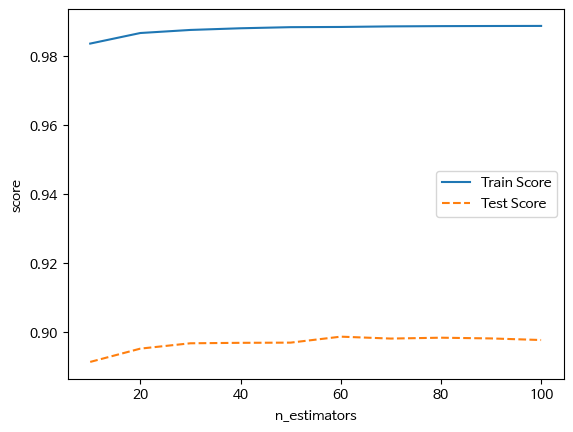

In [ ]:
plt.plot(para_n_tree, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_n_tree, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("n_estimators")
plt.legend()

랜덤포레스트의 나무개수가 증가할수록 모델의 성능은 좋아진다. train/test 데이터의 성능 차이가 가장 적은 (과적합 방지) 50개로 결정

최소 잎사귀 자료수에 따른 성능 변화


In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_leaf: 잎사귀 최소 자료 수
para_leaf = [n_leaf for n_leaf in range(1, 21)]

for v_min_samples_leaf in para_leaf:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 50,
                                min_samples_leaf = v_min_samples_leaf)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score

df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore
0,1,0.988,0.897
1,2,0.977,0.899
2,3,0.966,0.898
3,4,0.958,0.896
4,5,0.951,0.893
5,6,0.945,0.891
6,7,0.939,0.889
7,8,0.935,0.887
8,9,0.931,0.886
9,10,0.928,0.884


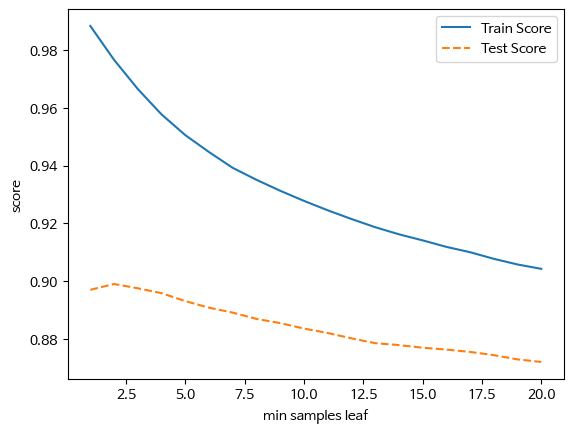

In [ ]:
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

최소 잎사귀 자료수가 증가할수록 모델의 설명력은 줄어든다.
train/test 데이터의 성능 변화를 고려하여 최소 잎사귀 자료수는 4개로 결정

최소분리노드 개수에 따른 모델의 성능 변화

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_split: 분할하기 위한 노드의 최소 자료 수
para_split = [n_split * 2for n_split in range(2, 21)]

for v_min_samples_split in para_split:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 50, min_samples_leaf = 4,
                               min_samples_split = v_min_samples_split)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score
df_score_split.round(3)

,MinSamplesSplit,TrainScore,TestScore
0,4,0.958,0.896
1,6,0.958,0.896
2,8,0.958,0.896
3,10,0.955,0.895
4,12,0.952,0.894
5,14,0.949,0.894
6,16,0.946,0.893
7,18,0.944,0.892
8,20,0.942,0.891
9,22,0.939,0.890


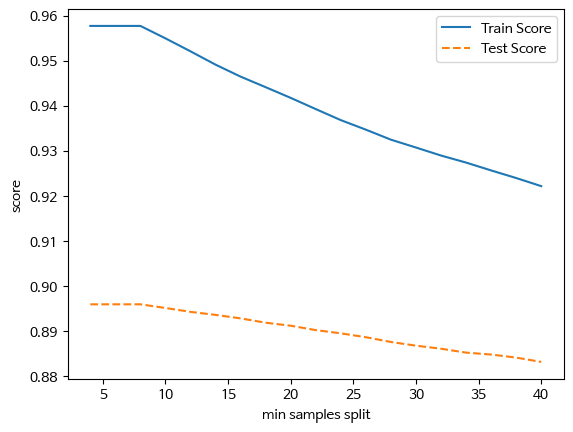

In [ ]:
# 모델 설명력 그래프 확인
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples split")
plt.legend()

최소분리노드가 늘어날수록 모델의 설명력은 저하된다.   
10개 이후부터 train/test 데이터 모두 설명력이 낮아지는 것으로 보아 최소분리노드는 10개로 결정

나무 최대 깊이에 따른 모델 성능 변화

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# max_depth: 최대 깊이 변경
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 50,
                               min_samples_leaf = 4, min_samples_split = 10,
                               max_depth = v_max_depth)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score

In [ ]:
df_score_depth.round(3)

,Depth,TrainScore,TestScore
0,1,0.497,0.522
1,2,0.674,0.673
2,3,0.770,0.759
3,4,0.829,0.816
4,5,0.870,0.848
5,6,0.895,0.864
6,7,0.915,0.874
7,8,0.928,0.882
8,9,0.937,0.887
9,10,0.943,0.890


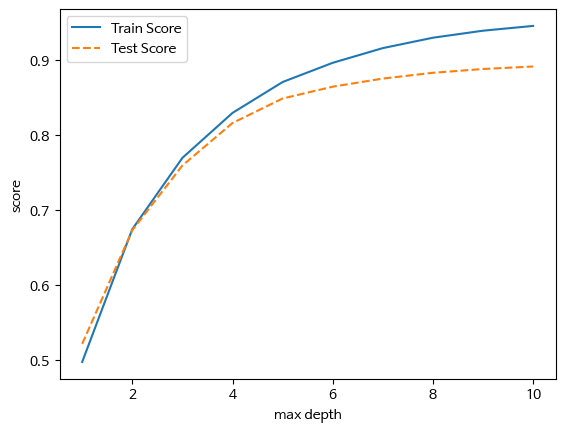

In [ ]:
# 모델 설명력 그래프 확인
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("max depth")
plt.legend()

나무깊이가 깊어질수록 모델의 설명력은 증가한다.   
다만 너무 깊어지면 과적합, 모델 복잡도 증가의 이슈가 있기 때문에 4개로 결정

최종 랜덤포레스트 모형

In [ ]:
rf_final = RandomForestRegressor(random_state=1234, n_estimators = 50, min_samples_leaf = 4,
                                 min_samples_split = 10, max_depth = 4)
rf_final.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(rf_final.score(df_train_x, df_train_y)))
# Test 데이터 설명력
print("Score on test set: {:.3f}".format(rf_final.score(df_test_x, df_test_y)))

Score on training set: 0.829
Score on test set: 0.816


In [ ]:
#실제값과 예측값 비교
test_pred = rf_final.predict(df_test_x)
print('test data의 실제값 : \n', df_test_y[:10])
print('test data의 예측값 : \n', test_pred[:10])

test data의 실제값 : 
 962      8.839178
3893     8.708836
4599    10.547840
3781     9.111712
5669     9.662297
5159     8.670129
2376    10.197194
5866     9.515447
4408     9.126824
3171     8.364809
Name: log_price, dtype: float64
test data의 예측값 : 
 [ 8.9119533   8.55305856  9.88228966  8.9175062   9.49685644  8.49317485
 10.09429979  8.90366284  9.34527997  8.53760247]


In [ ]:
# 파라미터 값 확인
rf_final.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 1234,
 'verbose': 0,
 'warm_start': False}

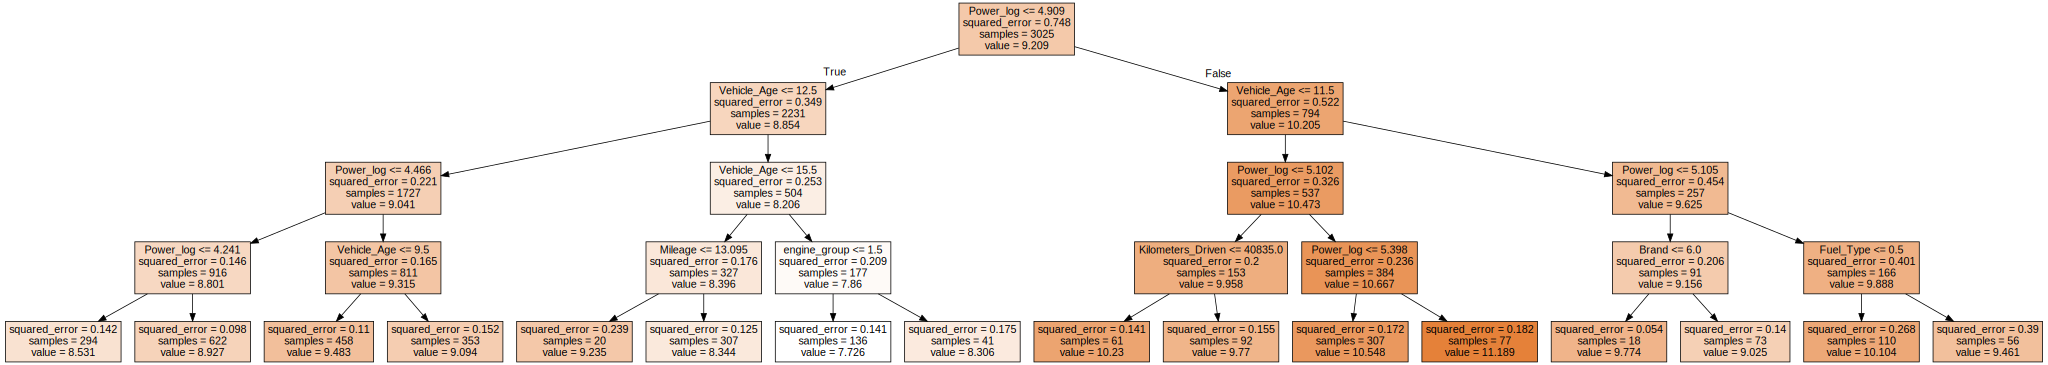

In [ ]:
# 변수명 저장
v_feature_name = df_train_x.columns
# 0번 트리
export_graphviz(rf_final.estimators_[0], out_file="rfr_final_0.dot", feature_names = v_feature_name ,
                impurity = True, filled = True)
# tree_final_0.dot 그리기
with open("rfr_final_0.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

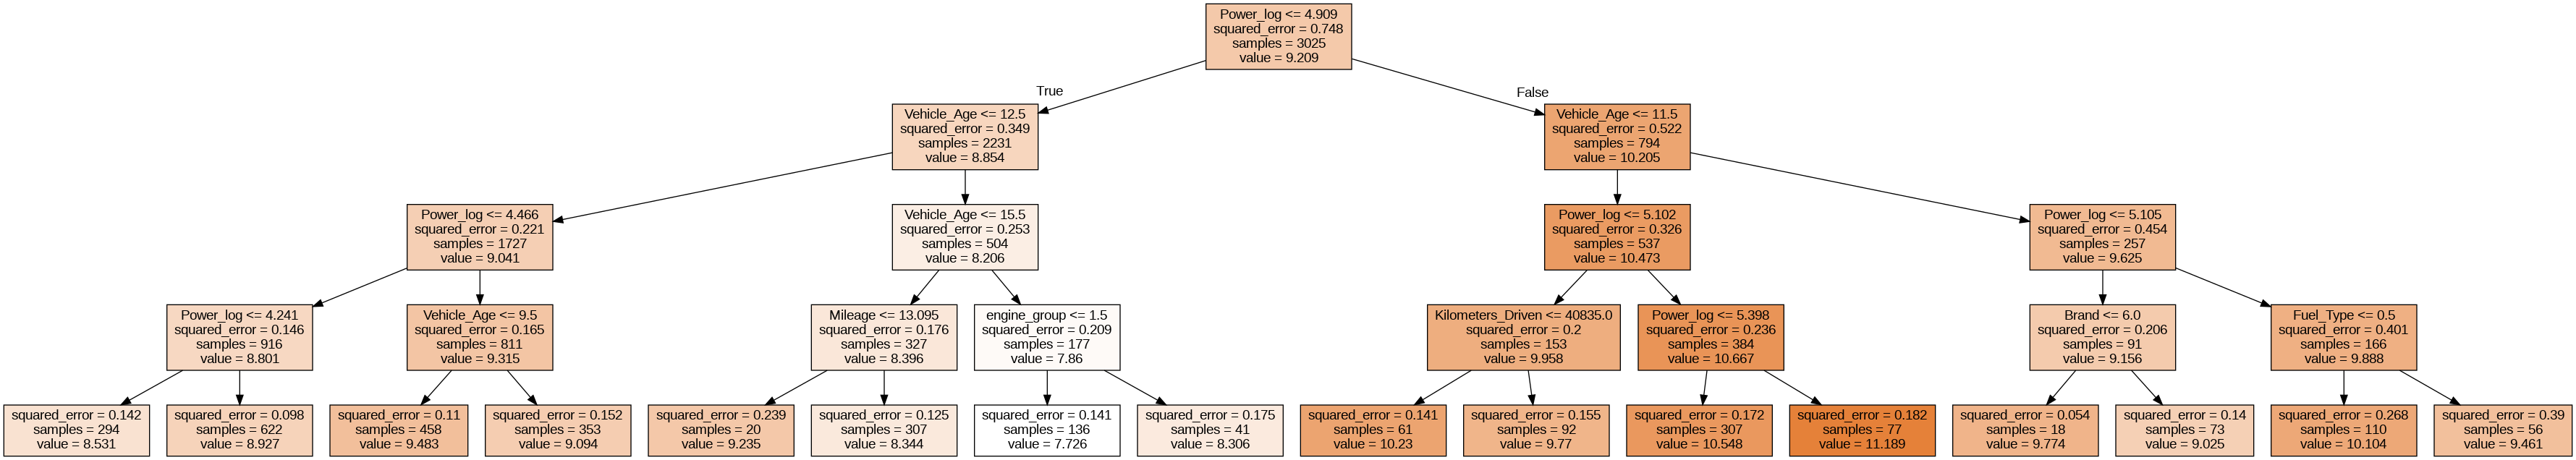

In [ ]:
import graphviz
import os

# 그래프 이미지로 변환 및 저장
os.system('dot -Tpng rfr_final_0.dot -o rfr_final_0.png')

# 저장된 이미지 파일을 출력
from IPython.display import Image
Image(filename='rfr_final_0.png')

최종 모형 변수 중요도 확인

In [ ]:
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = rf_final.feature_importances_

# df_feature_importance의 테이블을 중요도 순으로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
10,Power_log,0.740
7,Vehicle_Age,0.239
9,engine_group,0.012
2,Transmission,0.003
6,Brand,0.002
0,Kilometers_Driven,0.002
4,Mileage,0.001
1,Fuel_Type,0.001
5,Seats,0.000
3,Owner_Type,0.000


Text(0, 0.5, '변수')

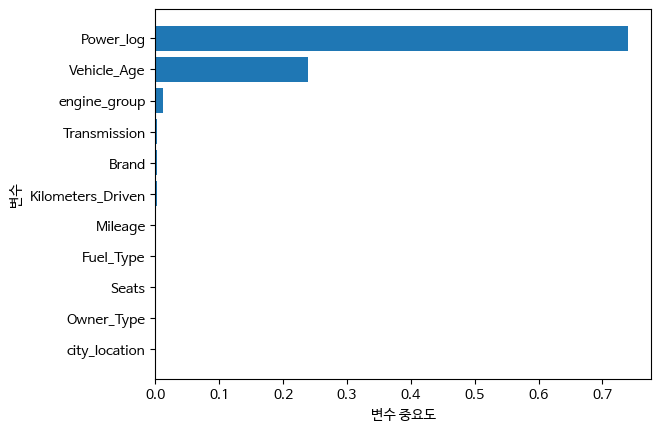

In [ ]:
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

In [ ]:
from sklearn.model_selection import cross_val_score



# cross_val_score()로 k-fold 교차 검증 수행
scores = cross_val_score(rf_final, df_raw_x, df_raw_y, cv=5)

print('교차 검증별 정확도:', np.round(scores, 4))
print('평균 검증 정확도:', np.round(np.mean(scores), 4))

교차 검증별 정확도: [0.8493 0.8221 0.8176 0.8439 0.7631]
평균 검증 정확도: 0.8192


In [ ]:
from sklearn.metrics import mean_squared_error

# 훈련 데이터와 테스트 데이터에 대한 예측값 계산
train_pred = rf_final.predict(df_train_x)
test_pred = rf_final.predict(df_test_x)

# 각 학습 데이터와 테스트 데이터의 MSE 값 계산
train_mse = mean_squared_error(df_train_y, train_pred)
test_mse = mean_squared_error(df_test_y, test_pred)

print("train data의 MSE:", train_mse)
print("test data의 MSE:", test_mse)


train data의 MSE: 0.12827028026271844
test data의 MSE: 0.14309727703056171


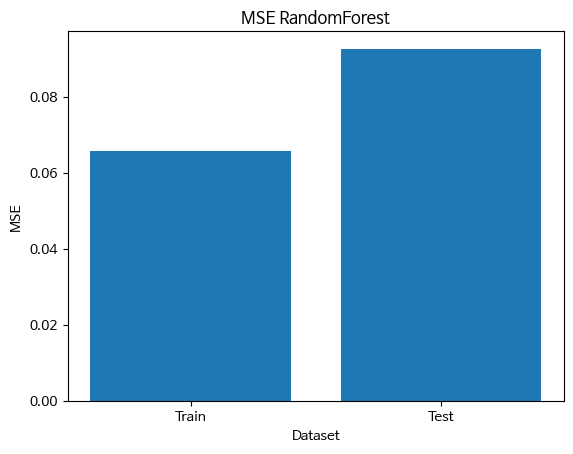

In [ ]:


# MSE 그래프 그리기
plt.bar(['Train', 'Test'], [train_mse, test_mse])
plt.xlabel('Dataset')
plt.ylabel('MSE')
plt.title('MSE RandomForest')
plt.show()


<h2>랜덤포레스트 최종 결론</h2>

랜덤포레스트의 최종 성능:  
- train : 0.829
- test : 0.816

교차검증 후 평균 검증 정확도:
- 평균 검증 정확도: 0.8192  

최종 모형에 사용된 파라미터:
- n_estimator : 50  
- min_samples_leaf: 4
- min_samples_split: 10
- max_depth : 4  

변수 중요도:
- Power_log : 중고차 가격 예측에 가장 큰 영향을 준 변수는 엔진의 최대출력이다.  
- Vehicle_Age : 중고차 가격 예측에 두번째로 큰 영향을 준 변수는 차량의 연식이다.   
- engine_group : 중고차 가격 예측에 세번째로 큰 영향을 준 변수로 배기량의 크기에 따라 가격 예측에 영향을 준다고 추정한다.


# 그래디언트 부스팅

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 예측/회귀 Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /real_final.csv")
df_raw.head(10)

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340
5,75000,3,1,1,21.10,814.0,5.0,11,12,3,0,8.189650,4.010963
6,86999,0,1,1,23.08,1461.0,5.0,22,11,4,1,8.587905,4.144721
7,36000,0,2,1,11.36,2755.0,8.0,29,8,2,3,10.197194,5.144583
8,64430,0,1,1,20.54,1598.0,5.0,30,11,2,1,8.983740,4.640537
9,65932,0,1,2,22.30,1248.0,5.0,28,12,3,1,8.003119,4.304065


In [ ]:
#engine 열 삭제
df_raw = df_raw.drop('Engine', axis=1)

In [ ]:
# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw["log_price"]
df_raw_x = df_raw.drop("log_price", axis = 1, inplace = False)
# train_test_split(X: 설명변수 데이터, Y: 목표변수 데이터, test_size = test 데이터 비율, random_state: random seed)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.2, random_state = 1234)

In [ ]:
#기본 그래디언트부스팅

gb_uncustomized = GradientBoostingRegressor(random_state=1234)
gb_uncustomized.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(gb_uncustomized.score (df_train_x, df_train_y)))
# Test 데이터 설명력
print("Score on test set: {:.3f}".format(gb_uncustomized.score (df_test_x, df_test_y)))

Score on training set: 0.928
Score on test set: 0.890


train데이터는 0.928 의 높은 설명력을 가지고   
test 데이터도 0.890 의 높은 설명력을 가진다.   
하지만 test데이터의 성능을 올리기 위해 파라미터 변경통해 성능 변화 알아볼 것.

트리 개수 변경에 따른 성능 변화

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# n_estimatos: 트리 수 변경(10~100)
para_n_tree = [n_tree * 10 for n_tree in range(1, 11)]

for v_n_estimators in para_n_tree:
    gb = GradientBoostingRegressor(random_state = 1234, n_estimators = v_n_estimators)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_n = pd.DataFrame()
df_score_n["Estimators"] = para_n_tree
df_score_n["TrainScore"] = train_score
df_score_n["TestScore"] = test_score

df_score_n.round(3)

,Estimators,TrainScore,TestScore
0,10,0.705,0.696
1,20,0.843,0.825
2,30,0.881,0.857
3,40,0.897,0.870
4,50,0.906,0.876
5,60,0.912,0.880
6,70,0.918,0.883
7,80,0.922,0.886
8,90,0.925,0.887
9,100,0.928,0.890


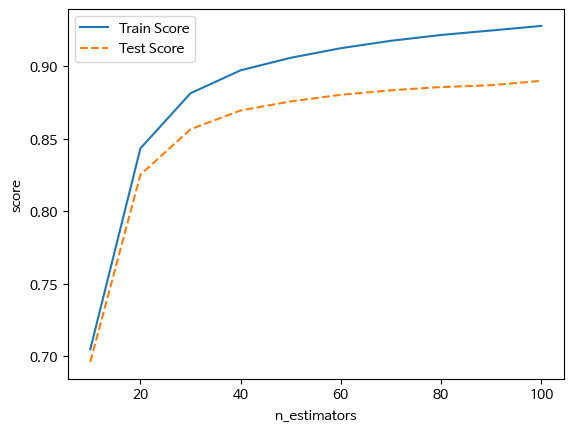

In [ ]:
# 모델 설명력 그래프 확인
plt.plot(para_n_tree, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_n_tree, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("n_estimators")
plt.legend()

트리개수 많아질수록 모델의 설명력은 높아지지만 과적합 우려.  
train/test 성능 변화 고려하여 30개 지정

잎사귀 최소 자료수에 따른 성능 변화

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_leaf: 잎사귀 최소 자료 수
para_leaf = [n_leaf for n_leaf in range(1, 21)]

for v_min_samples_leaf in para_leaf:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30,
                                   min_samples_leaf = v_min_samples_leaf)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score

df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore
0,1,0.881,0.857
1,2,0.881,0.857
2,3,0.881,0.857
3,4,0.881,0.857
4,5,0.881,0.857
5,6,0.881,0.857
6,7,0.881,0.857
7,8,0.881,0.857
8,9,0.881,0.857
9,10,0.881,0.857


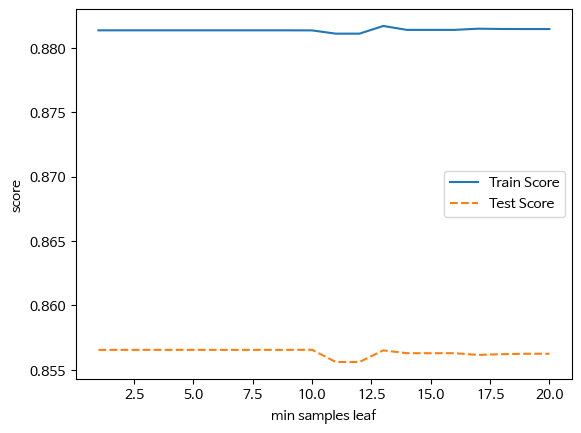

In [ ]:
# 모델 설명력 그래프 확인
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

최소 잎사귀 자료수에 따라 모델의 성능변화는 크게 달라지지 않지만 13개로 지정 , 14부터 train,test성능 저하

분할 최소 노드 자료수에 따른 성능 변화

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_split: 분할하기 위한 노드의 최소 자료 수
para_split = [n_split * 2 for n_split in range(1, 21)]

for v_min_samples_split in para_split:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 13,
                                   min_samples_split = v_min_samples_split)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score

df_score_split.round(3)

,MinSamplesSplit,TrainScore,TestScore
0,2,0.882,0.857
1,4,0.882,0.857
2,6,0.882,0.857
3,8,0.882,0.857
4,10,0.882,0.857
5,12,0.882,0.857
6,14,0.882,0.857
7,16,0.882,0.857
8,18,0.882,0.857
9,20,0.882,0.857


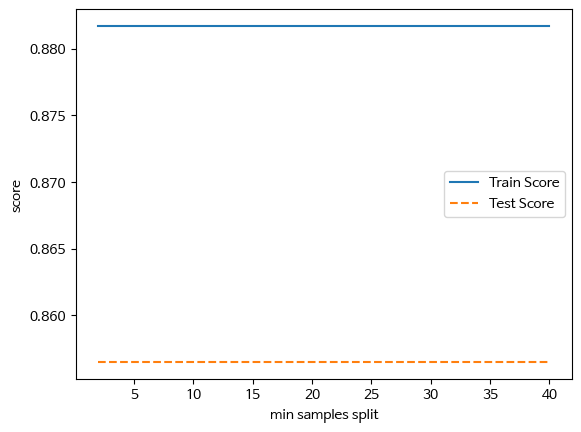

In [ ]:
# 모델 설명력 그래프 확인 : 22개
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples split")
plt.legend()

최소분할노드 개수에 따라 train/test 모두 성능 변화 없는 것을 볼 수 있음.  
따라서 20개로 지정

최대 나무 깊이 변경에 따른 성능 변화

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# max_depth: 최대 깊이 변경
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 13,
                                   min_samples_split = 20, max_depth = v_max_depth)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score

df_score_depth.round(3)

,Depth,TrainScore,TestScore
0,1,0.733,0.730
1,2,0.843,0.827
2,3,0.882,0.857
3,4,0.904,0.875
4,5,0.921,0.883
5,6,0.934,0.891
6,7,0.945,0.894
7,8,0.952,0.897
8,9,0.957,0.898
9,10,0.960,0.899


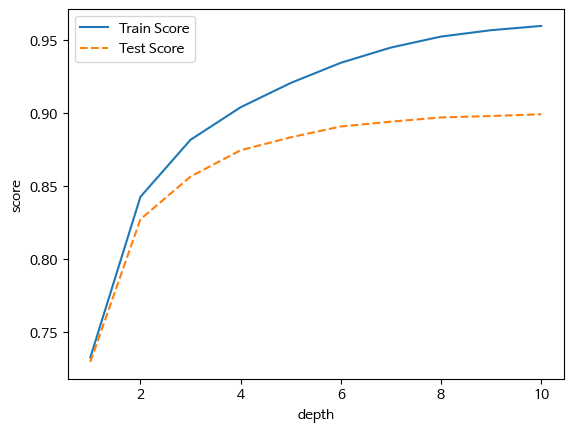

In [ ]:
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("depth")
plt.legend()

나무깊이가 깊어질수록 모델의 성능은 증가한다.  
하지만 너무 깊어지면 과적합 이슈와 모델의 복잡도가 커지기 때문에 train/test 성능 변화 고려하여 3개로 지정

학습률 변화에 따른 모델의 성능 변화

In [ ]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# learning rate: 학습률 변경 0.1 ~ 0.9
para_lr = [lr * 0.1 for lr in range(1, 10)]

for v_learning_rate in para_lr:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 13,
                                   min_samples_split = 20, max_depth = 3, learning_rate = v_learning_rate)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_lr = pd.DataFrame()
df_score_lr["LearningRate"] = para_lr
df_score_lr["TrainScore"] = train_score
df_score_lr["TestScore"] = test_score

df_score_lr.round(3)

,LearningRate,TrainScore,TestScore
0,0.1,0.882,0.857
1,0.2,0.913,0.881
2,0.3,0.922,0.882
3,0.4,0.927,0.884
4,0.5,0.929,0.883
5,0.6,0.929,0.886
6,0.7,0.931,0.884
7,0.8,0.934,0.893
8,0.9,0.934,0.886


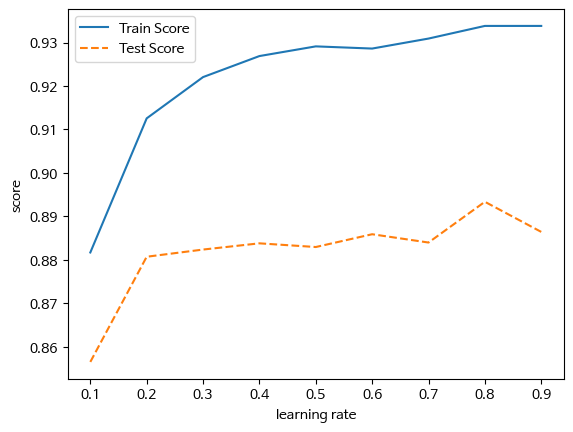

In [ ]:
# 모델 설명력 그래프 확인
plt.plot(para_lr, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_lr, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("learning rate")
plt.legend()

학습률이 너무 작으면 학습이 느려지고 학습률이 너무 크면 과적합 위험이 큼.  
따라서 train/test 성능 변화를 고려하여 0.2로 결정

최종 모델 선정

In [ ]:
# 최종모델 선택
gb_final = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 13,
                                     min_samples_split = 20, max_depth = 3, learning_rate = 0.2)
gb_final.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(gb_final.score(df_train_x, df_train_y)))
# Test 데이터 설명력
print("Score on test set: {:.3f}".format(gb_final.score(df_test_x, df_test_y)))

Score on training set: 0.913
Score on test set: 0.881


In [ ]:
# feature_importances_: 설명변수의 중요도
v_feature_name = df_train_x.columns

# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = gb_final.feature_importances_
# df_feature_importance의 테이블을 중요도별로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
10,Power_log,0.570
7,Vehicle_Age,0.238
2,Transmission,0.079
9,engine_group,0.043
1,Fuel_Type,0.029
0,Kilometers_Driven,0.012
8,city_location,0.012
6,Brand,0.011
5,Seats,0.004
4,Mileage,0.003


Text(0, 0.5, '변수')

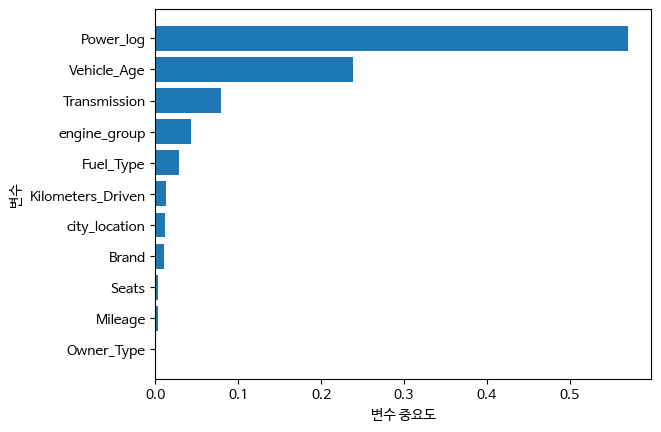

In [ ]:
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

In [ ]:
from sklearn.model_selection import cross_val_score



# cross_val_score()로 k-fold 교차 검증 수행
scores = cross_val_score(gb_final, df_raw_x, df_raw_y, cv=5)

print('교차 검증별 정확도:', np.round(scores, 4))
print('평균 검증 정확도:', np.round(np.mean(scores), 4))

교차 검증별 정확도: [0.9194 0.9056 0.8983 0.9155 0.8344]
평균 검증 정확도: 0.8946


In [ ]:
from sklearn.metrics import mean_squared_error

# 훈련 데이터와 테스트 데이터에 대한 예측값 계산
train_pred = gb_final.predict(df_train_x)
test_pred = gb_final.predict(df_test_x)

# 각 학습 데이터와 테스트 데이터의 MSE 값 계산
train_mse = mean_squared_error(df_train_y, train_pred)
test_mse = mean_squared_error(df_test_y, test_pred)

print("train data의 MSE:", train_mse)
print("test data의 MSE:", test_mse)

train data의 MSE: 0.06575612553012111
test data의 MSE: 0.09275868536297842


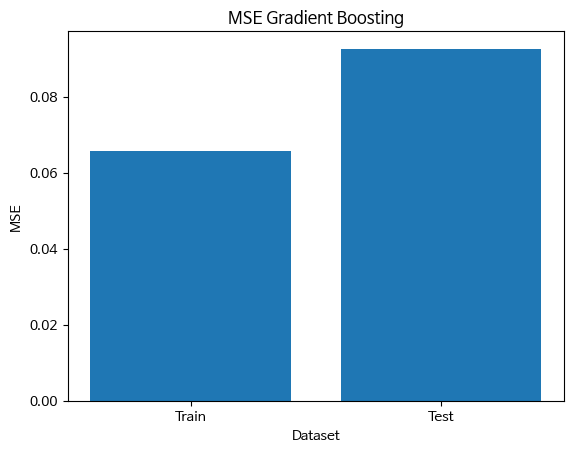

In [ ]:

# MSE 그래프 그리기
plt.bar(['Train', 'Test'], [train_mse, test_mse])
plt.xlabel('Dataset')
plt.ylabel('MSE')
plt.title('MSE Gradient Boosting')
plt.show()


In [ ]:
TROUT = pd.DataFrame(df_train_y)
TROUT['yhgb'] = gb_final.predict(df_train_x)
TSOUT = pd.DataFrame(df_test_y)
TSOUT['yhgb'] = gb_final.predict(df_test_x)
TROUT.head()

,log_price,yhgb
924,8.914070,9.108684
219,9.523325,9.400387
1438,8.416982,8.399091
4502,8.839178,8.831029
4698,7.173207,7.600286


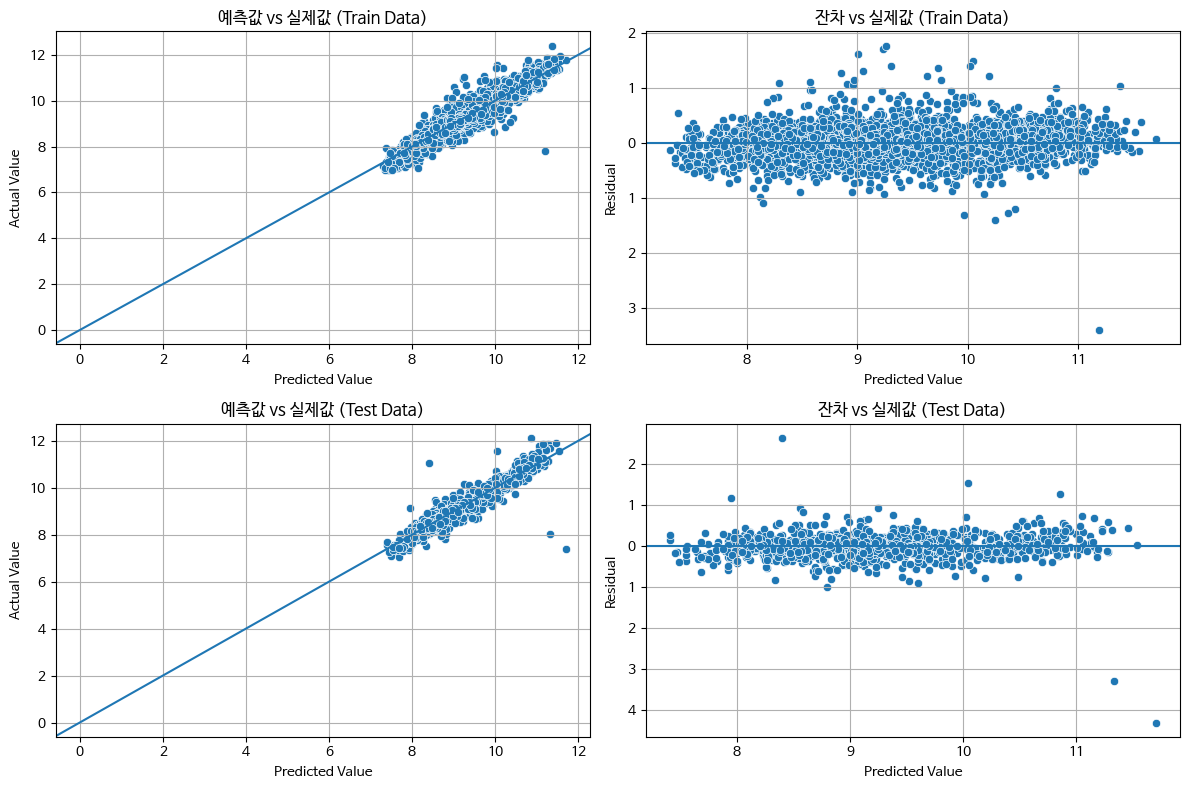

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프 객체 생성
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# 첫 번째 그래프: Train Data 의 예측값 vs 실제값
g1 = sns.scatterplot(x='yhgb', y='log_price', data=TROUT, ax=axs[0, 0])
g1.axline((0, 0), slope=1)
g1.grid()
g1.set_xlabel('Predicted Value')
g1.set_ylabel('Actual Value')
g1.set_title('예측값 vs 실제값 (Train Data)')

# 두 번째 그래프: Train Data의 잔차 vs 실제값
residuals = TROUT['log_price'] - TROUT['yhgb']
g2 = sns.scatterplot(x='yhgb', y=residuals, data=TROUT, ax=axs[0, 1])
g2.axhline(0)
g2.grid()
g2.set_xlabel('Predicted Value')
g2.set_ylabel('Residual')
g2.set_title('잔차 vs 실제값 (Train Data)')

# 세 번째 그래프: Test Data 의 예측값 vs 실제값
g3 = sns.scatterplot(x='yhgb', y='log_price', data=TSOUT, ax=axs[1, 0])
g3.axline((0, 0), slope=1)
g3.grid()
g3.set_xlabel('Predicted Value')
g3.set_ylabel('Actual Value')
g3.set_title('예측값 vs 실제값 (Test Data)')

# 네 번째 그래프: Test Data의 잔차 vs 실제값
residuals = TSOUT['log_price'] - TSOUT['yhgb']
g4 = sns.scatterplot(x=TSOUT['yhgb'], y=residuals, data=TSOUT, ax=axs[1, 1])
g4.axhline(0)
g4.grid()
g4.set_xlabel('Predicted Value')
g4.set_ylabel('Residual')
g4.set_title('잔차 vs 실제값 (Test Data)')

plt.tight_layout()
plt.show()


위 그래프는 Train/Test 데이터에서 그래디언트 부스팅이 목표변수인 log_price를 얼마나 잘 예측하는 지를 예측값vs실제값, 잔차vs실제값 비교를 통해 모델의 성능을 시각화함.   
최종모델 성능 짱 좋다!

<h2>그래디언트 부스팅 결론</h2>


그래디언트 부스팅의 최종 성능:  
- train : 0.913
- test : 0.881

교차검증 후 평균 검증 정확도:

평균 검증 정확도: 0.8946

최종 모형에 사용된 파라미터:
- n_estimator : 30  
- min_samples_leaf: 13
- min_samples_split: 20
- max_depth : 3
- learning_late : 0.2

변수 중요도
- Power_log: 엔진의 최대출력은 중고차 가격을 예측하는 데 가장 큰 영향을 주고있다.
- Vehicle_Age: 자동차 연식은 중고차 가격을 예측하는 데 두번쩨로 큰 영향을 주고있다.
- Transmission: 자동차 변속기(수동/자동) 에 따라 가격을 예측하는데 영향을 주고있다.
- engine_group: 배기량 크기에 따라 중고차 가격을 예측하는데 중요도를 가지고 있다.

최종 모형

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
g=sns.scatterplot(x='pred', y='log_price', data=predict, ax=axs[0]);
g.axline((0), slope=1); g.grid()

g=sns.scatterplot(x='df_test_y', y='log_price', data=predict, ax=axs[1]);
g.axline((0), slope=1); g.grid()


ValueError: 'vertices' must be 2D with shape (M, 2). Your input has shape (1,).

Error in callback <function _draw_all_if_interactive at 0x7979a5121120> (for post_execute):


ValueError: object of too small depth for desired array

ValueError: object of too small depth for desired array

<Figure size 800x400 with 2 Axes>